In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("unemployment in india.csv")

In [3]:
df.columns = df.columns.str.strip()

### understanding data

In [4]:
print(df.shape)
print(df.dtypes)

(768, 7)
Region                                         str
Date                                           str
Frequency                                      str
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                           str
dtype: object


In [5]:
print(df.isnull().sum())

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


#### Convert Date column to actual datetime

In [6]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

In [7]:
df = df.dropna(subset=['Date', 'Estimated Unemployment Rate (%)'])

## EDA

In [8]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
print(region_avg)

month_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()
print(month_avg)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64
Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.5534

### Time-series line chart

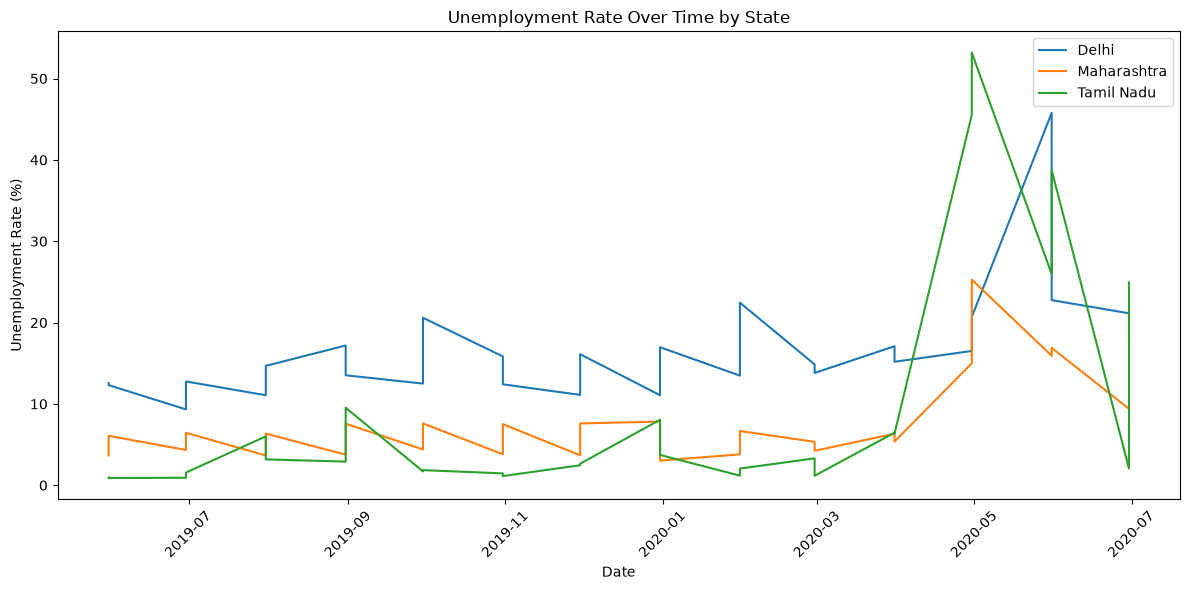

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

top_states = ['Delhi', 'Maharashtra', 'Tamil Nadu']  # adjust to match your dataset's exact region names

plt.figure(figsize=(12, 6))
for state in top_states:
    state_data = df[df['Region'] == state].sort_values('Date')
    plt.plot(state_data['Date'], state_data['Estimated Unemployment Rate (%)'], label=state)

plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.title('Unemployment Rate Over Time by State')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Bar chart

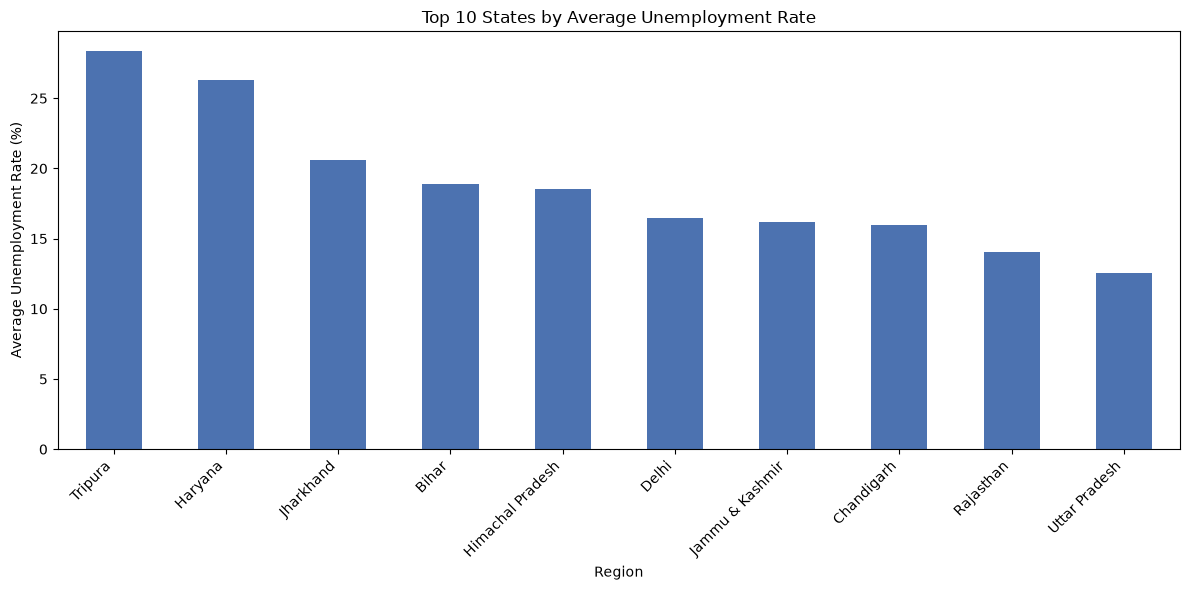

In [14]:
plt.figure(figsize=(12, 6))
region_avg.head(10).plot(kind='bar', color='#4c72b0')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('Top 10 States by Average Unemployment Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

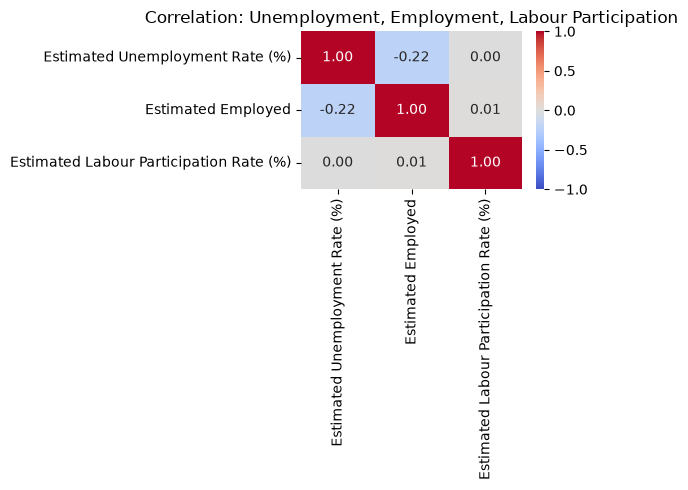

In [15]:
corr_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation: Unemployment, Employment, Labour Participation')
plt.tight_layout()
plt.show()

### Pre-COVID vs post-COVID comparison

In [16]:
covid_cutoff = pd.Timestamp('2020-03-01')  # India's lockdown began late March 2020

pre_covid = df[df['Date'] < covid_cutoff]
post_covid = df[df['Date'] >= covid_cutoff]

comparison = pd.DataFrame({
    'Pre-COVID Mean': [pre_covid['Estimated Unemployment Rate (%)'].mean(),
                        pre_covid['Estimated Employed'].mean(),
                        pre_covid['Estimated Labour Participation Rate (%)'].mean()],
    'Post-COVID Mean': [post_covid['Estimated Unemployment Rate (%)'].mean(),
                         post_covid['Estimated Employed'].mean(),
                         post_covid['Estimated Labour Participation Rate (%)'].mean()]
}, index=['Unemployment Rate (%)', 'Employed', 'Labour Participation Rate (%)'])

print(comparison)

                               Pre-COVID Mean  Post-COVID Mean
Unemployment Rate (%)            9.509534e+00     1.777436e+01
Employed                         7.466028e+06     6.517203e+06
Labour Participation Rate (%)    4.388612e+01     3.933005e+01
